## Análise das vendas de produtos de verão no Wish

Aqui eu baixei um conjunto de dados da wish no kaggle. Meu objetivo vai ser entender que fatores são os mais importantes para definir o sucesso de determinados produtos dentro da plataforma. 

https://www.kaggle.com/datasets/jmmvutu/summer-products-and-sales-in-ecommerce-wish

### Perguntas de Negócio

Dando uma olhada rápida no conjunto de dados eu selecionei algumas perguntas que vou tentar resolver no decorrer deste projeto

- Produtos com maior discrepância entre preço real e de retail vendem mais?
- Ad boost aumentam as vendas?
- Avaliações melhores aumentam vendas?
- Badges importam?
- Quantidade de tags auxiliam vendas?
- Tags com maiores vendas?
- Shipping analysis

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import numpy as np

In [2]:
df_produtos = pd.read_csv("summer-products-with-rating-and-performance_2020-08.csv")

In [3]:
[i for i in df_produtos.columns]

['title',
 'title_orig',
 'price',
 'retail_price',
 'currency_buyer',
 'units_sold',
 'uses_ad_boosts',
 'rating',
 'rating_count',
 'rating_five_count',
 'rating_four_count',
 'rating_three_count',
 'rating_two_count',
 'rating_one_count',
 'badges_count',
 'badge_local_product',
 'badge_product_quality',
 'badge_fast_shipping',
 'tags',
 'product_color',
 'product_variation_size_id',
 'product_variation_inventory',
 'shipping_option_name',
 'shipping_option_price',
 'shipping_is_express',
 'countries_shipped_to',
 'inventory_total',
 'has_urgency_banner',
 'urgency_text',
 'origin_country',
 'merchant_title',
 'merchant_name',
 'merchant_info_subtitle',
 'merchant_rating_count',
 'merchant_rating',
 'merchant_id',
 'merchant_has_profile_picture',
 'merchant_profile_picture',
 'product_url',
 'product_picture',
 'product_id',
 'theme',
 'crawl_month']

* Selecionando colunas que serão utilizadas 

In [4]:
colunas = ["title",
 "price",
 "retail_price",
 "currency_buyer",
 "units_sold",
 "uses_ad_boosts",
 "rating",
 "rating_count",
 "badges_count",
 "badge_product_quality",
 "badge_fast_shipping",
 "tags",
 "product_color",
 "product_variation_size_id",
 "product_variation_inventory",
 "shipping_is_express",
 "countries_shipped_to",
 "inventory_total",
 "has_urgency_banner",
 "origin_country",
 "merchant_rating_count",
 "merchant_rating",]

## 1. Análise da qualidade dos dados

In [5]:
df_produtos = df_produtos[colunas]

In [6]:
df_produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1573 entries, 0 to 1572
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        1573 non-null   object 
 1   price                        1573 non-null   float64
 2   retail_price                 1573 non-null   int64  
 3   currency_buyer               1573 non-null   object 
 4   units_sold                   1573 non-null   int64  
 5   uses_ad_boosts               1573 non-null   int64  
 6   rating                       1573 non-null   float64
 7   rating_count                 1573 non-null   int64  
 8   badges_count                 1573 non-null   int64  
 9   badge_product_quality        1573 non-null   int64  
 10  badge_fast_shipping          1573 non-null   int64  
 11  tags                         1573 non-null   object 
 12  product_color                1532 non-null   object 
 13  product_variation_

### 1.1. Análise de dados ausentes

In [7]:
df_produtos.isna().sum()

title                             0
price                             0
retail_price                      0
currency_buyer                    0
units_sold                        0
uses_ad_boosts                    0
rating                            0
rating_count                      0
badges_count                      0
badge_product_quality             0
badge_fast_shipping               0
tags                              0
product_color                    41
product_variation_size_id        14
product_variation_inventory       0
shipping_is_express               0
countries_shipped_to              0
inventory_total                   0
has_urgency_banner             1100
origin_country                   17
merchant_rating_count             0
merchant_rating                   0
dtype: int64

As colunas "product_color", "product_variation_size_id", "has_urgency_banner" e "origin_country" possuem dados sem valores.

In [8]:
df_produtos.loc[df_produtos["product_color"].isna(),"product_color"] = ""
df_produtos.loc[df_produtos["product_variation_size_id"].isna(),"product_variation_size_id"] = "" 
df_produtos.loc[df_produtos["has_urgency_banner"].isna(),"has_urgency_banner"] = 0
df_produtos.loc[df_produtos["origin_country"].isna(), "origin_country"] = "" 

In [9]:
df_produtos.isna().sum()

title                          0
price                          0
retail_price                   0
currency_buyer                 0
units_sold                     0
uses_ad_boosts                 0
rating                         0
rating_count                   0
badges_count                   0
badge_product_quality          0
badge_fast_shipping            0
tags                           0
product_color                  0
product_variation_size_id      0
product_variation_inventory    0
shipping_is_express            0
countries_shipped_to           0
inventory_total                0
has_urgency_banner             0
origin_country                 0
merchant_rating_count          0
merchant_rating                0
dtype: int64

### 1.2. Separando colunas categóricas e numéricas

In [10]:
df_produtos.describe()

,price,retail_price,units_sold,uses_ad_boosts,rating,rating_count,badges_count,badge_product_quality,badge_fast_shipping,product_variation_inventory,shipping_is_express,countries_shipped_to,inventory_total,has_urgency_banner,merchant_rating_count,merchant_rating
count,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1573.000000,1.573000e+03,1573.000000
mean,8.325372,23.288620,4339.005086,0.432931,3.820896,889.659250,0.105531,0.074380,0.012715,33.081373,0.002543,40.456453,49.821360,0.300699,2.649583e+04,4.032345
std,3.932030,30.357863,9356.539302,0.495639,0.515374,1983.928834,0.340709,0.262472,0.112075,21.353137,0.050379,20.301203,2.562799,0.458708,7.847446e+04,0.204768
min,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,6.000000,1.000000,0.000000,0.000000e+00,2.333333
25%,5.810000,7.000000,100.000000,0.000000,3.550000,24.000000,0.000000,0.000000,0.000000,6.000000,0.000000,31.000000,50.000000,0.000000,1.987000e+03,3.917353
50%,8.000000,10.000000,1000.000000,0.000000,3.850000,150.000000,0.000000,0.000000,0.000000,50.000000,0.000000,40.000000,50.000000,0.000000,7.936000e+03,4.040650
75%,11.000000,26.000000,5000.000000,1.000000,4.110000,855.000000,0.000000,0.000000,0.000000,50.000000,0.000000,43.000000,50.000000,1.000000,2.456400e+04,4.161797
max,49.000000,252.000000,100000.000000,1.000000,5.000000,20744.000000,3.000000,1.000000,1.000000,50.000000,1.000000,140.000000,50.000000,1.000000,2.174765e+06,5.000000


In [11]:
colunas_categoricas = [i for i in colunas if i not in df_produtos.describe().columns]
colunas_numericas = df_produtos.describe().columns
colunas_categoricas

['title',
 'currency_buyer',
 'tags',
 'product_color',
 'product_variation_size_id',
 'origin_country']

In [12]:
colunas_categoricas

['title',
 'currency_buyer',
 'tags',
 'product_color',
 'product_variation_size_id',
 'origin_country']

In [13]:
colunas_numericas

Index(['price', 'retail_price', 'units_sold', 'uses_ad_boosts', 'rating',
       'rating_count', 'badges_count', 'badge_product_quality',
       'badge_fast_shipping', 'product_variation_inventory',
       'shipping_is_express', 'countries_shipped_to', 'inventory_total',
       'has_urgency_banner', 'merchant_rating_count', 'merchant_rating'],
      dtype='object')

## 2. Análise exploratória dos dados

### 2.1. Análise de distribuição dos dados

#### 2.1.1 Dados categóricos

In [14]:
colunas_categoricas

['title',
 'currency_buyer',
 'tags',
 'product_color',
 'product_variation_size_id',
 'origin_country']

In [15]:
df_produtos["tags"] 

0       Summer,Fashion,womenunderwearsuit,printedpajam...
1       Mini,womens dresses,Summer,Patchwork,fashion d...
2       Summer,cardigan,women beachwear,chiffon,Sexy w...
3       Summer,Shorts,Cotton,Cotton T Shirt,Sleeve,pri...
4       Summer,Plus Size,Lace,Casual pants,Bottom,pant...
                              ...                        
1568    bohemia,Plus Size,dandelionfloralprinted,short...
1569    Summer,Panties,Elastic,Lace,Casual pants,casua...
1570    runningshort,Beach Shorts,beachpant,menbeachsh...
1571    Summer,fashion women,Fashion,Lace,Dresses,Dres...
1572    Summer,Leggings,slim,Yoga,pants,Slim Fit,Women...
Name: tags, Length: 1573, dtype: object

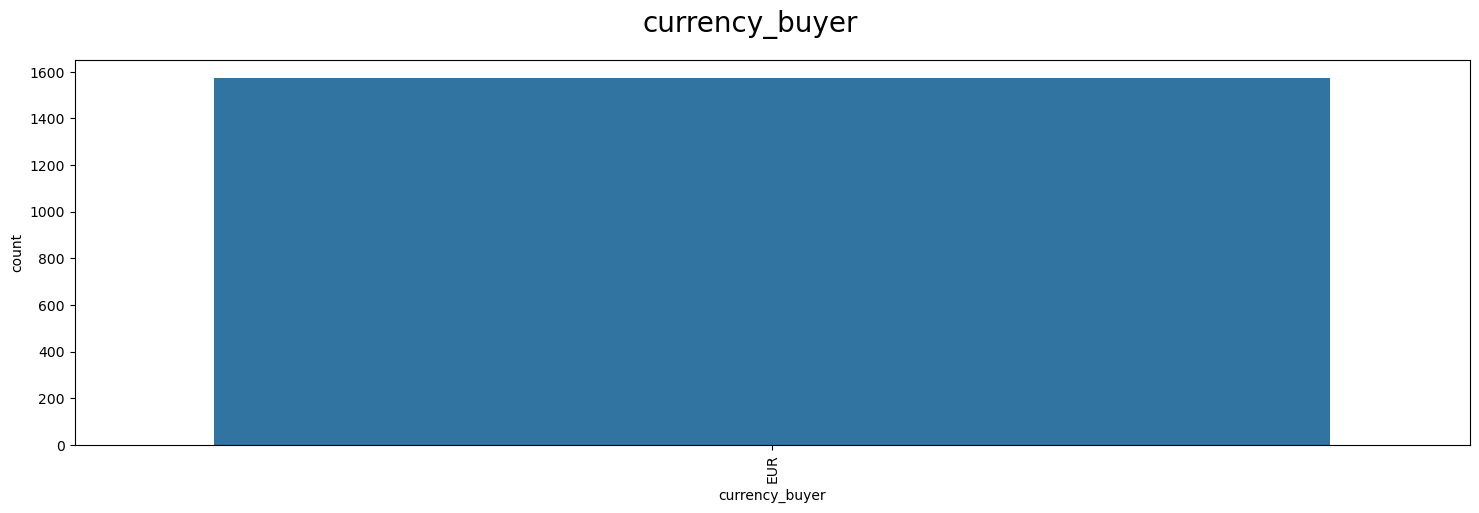

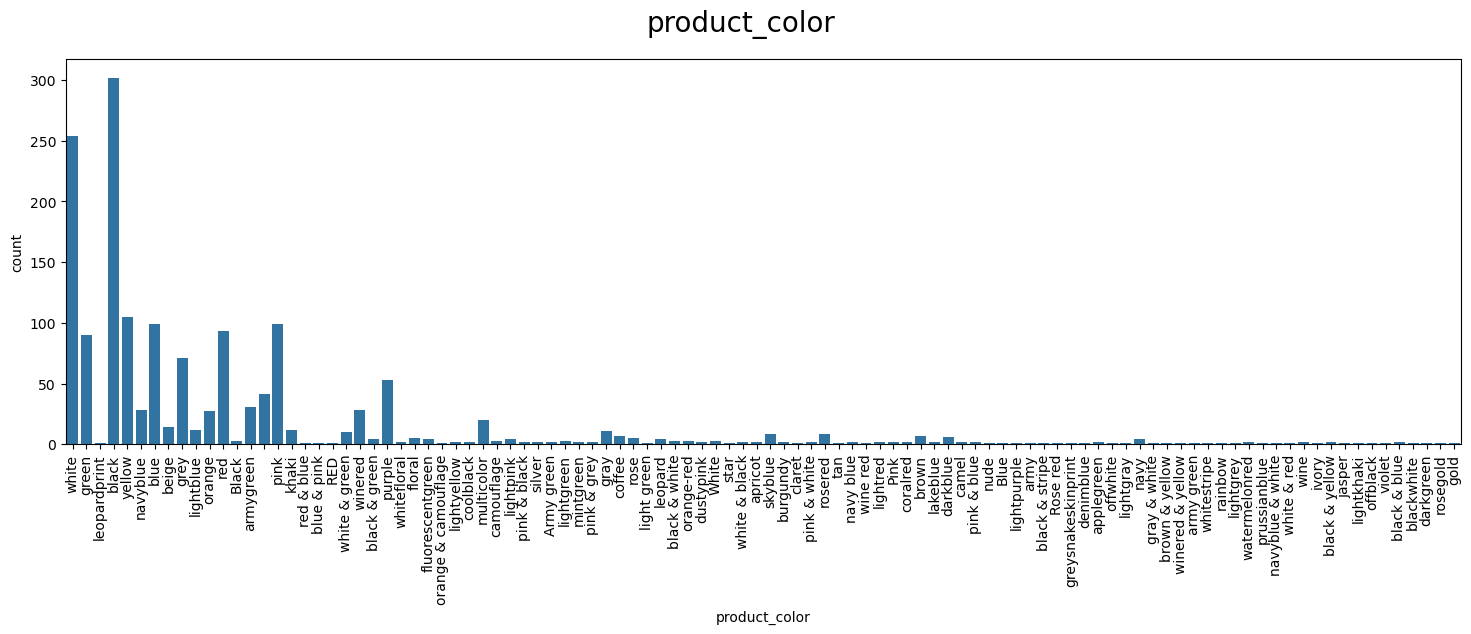

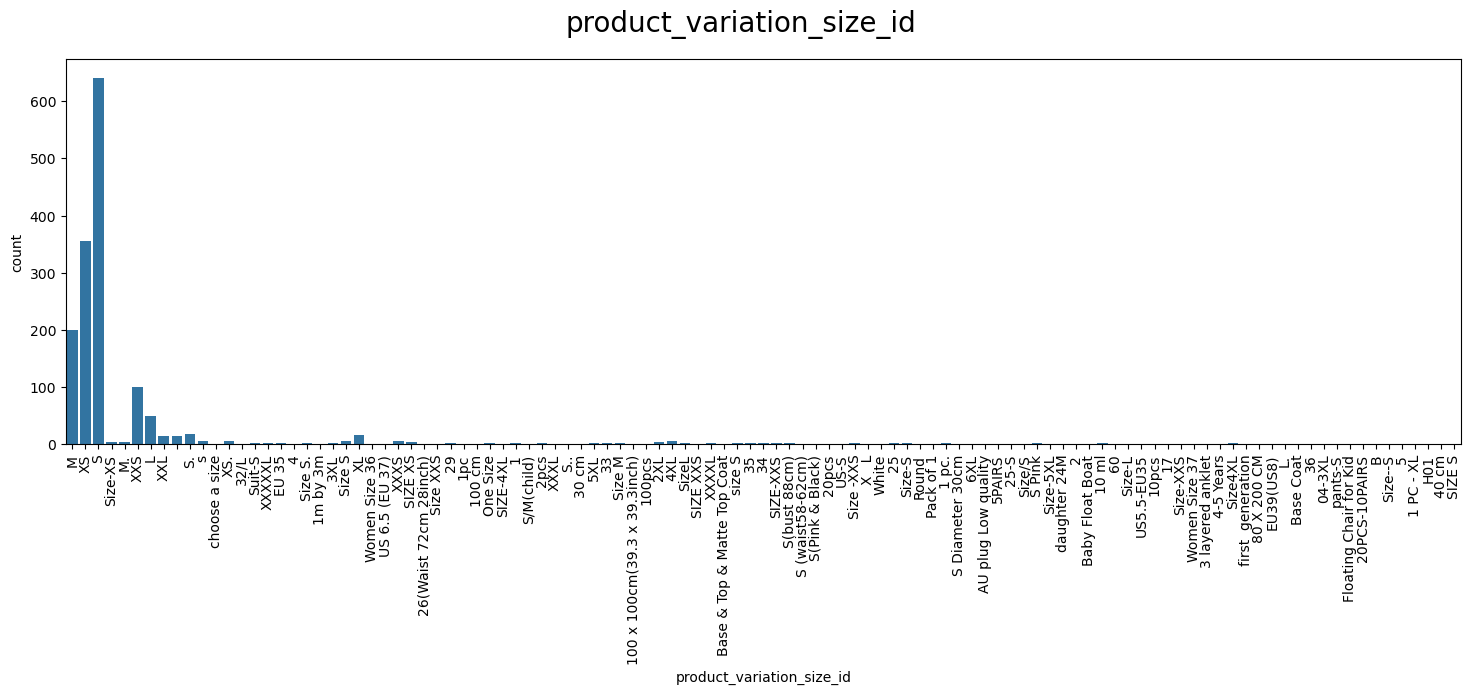

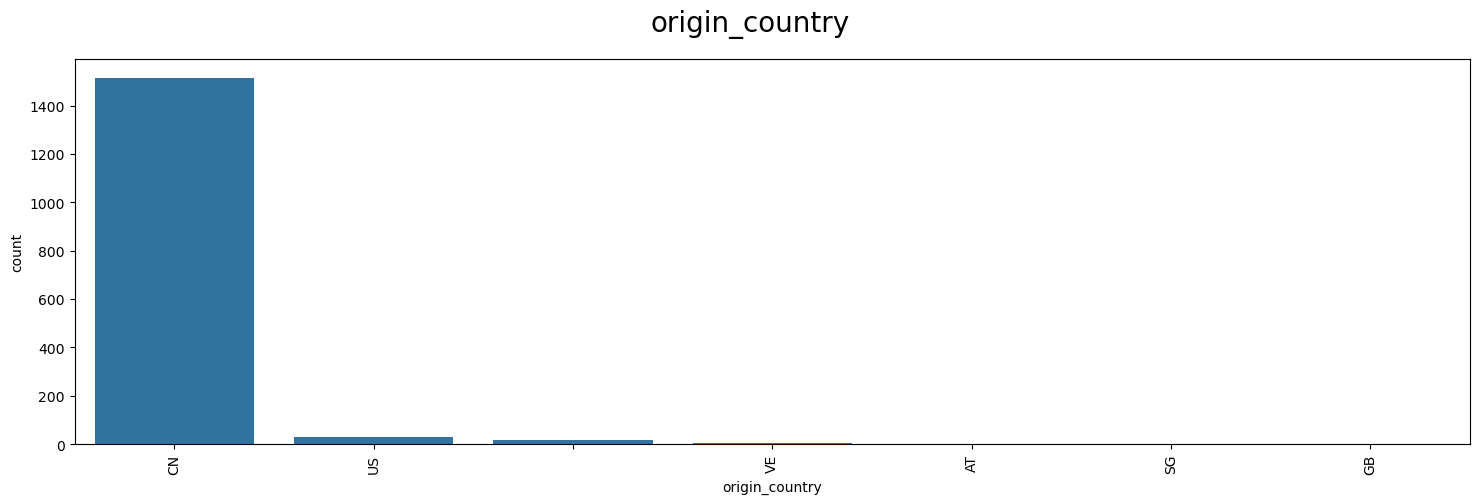

In [16]:
for colunas in colunas_categoricas:
    if colunas not in ["title", "tags"]:
        f, axes = plt.subplots(1,1,figsize=(18,5))
        sns.countplot(x=colunas, data = df_produtos)
        plt.xticks(rotation=90)
        plt.suptitle(colunas,fontsize=20)
        plt.show()

#### 2.1.2. Dados numéricos

In [17]:
colunas_numericas

Index(['price', 'retail_price', 'units_sold', 'uses_ad_boosts', 'rating',
       'rating_count', 'badges_count', 'badge_product_quality',
       'badge_fast_shipping', 'product_variation_inventory',
       'shipping_is_express', 'countries_shipped_to', 'inventory_total',
       'has_urgency_banner', 'merchant_rating_count', 'merchant_rating'],
      dtype='object')

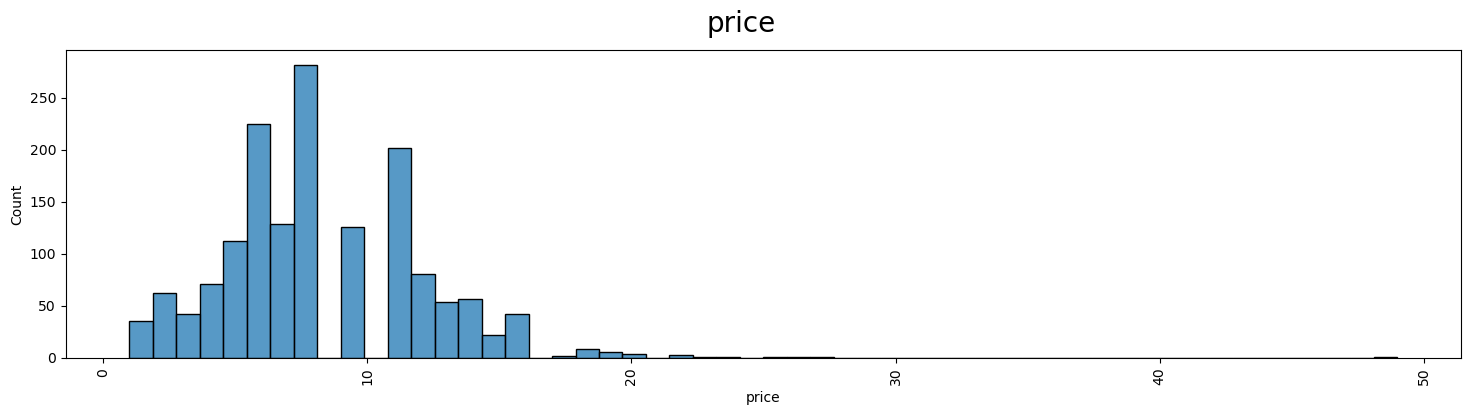

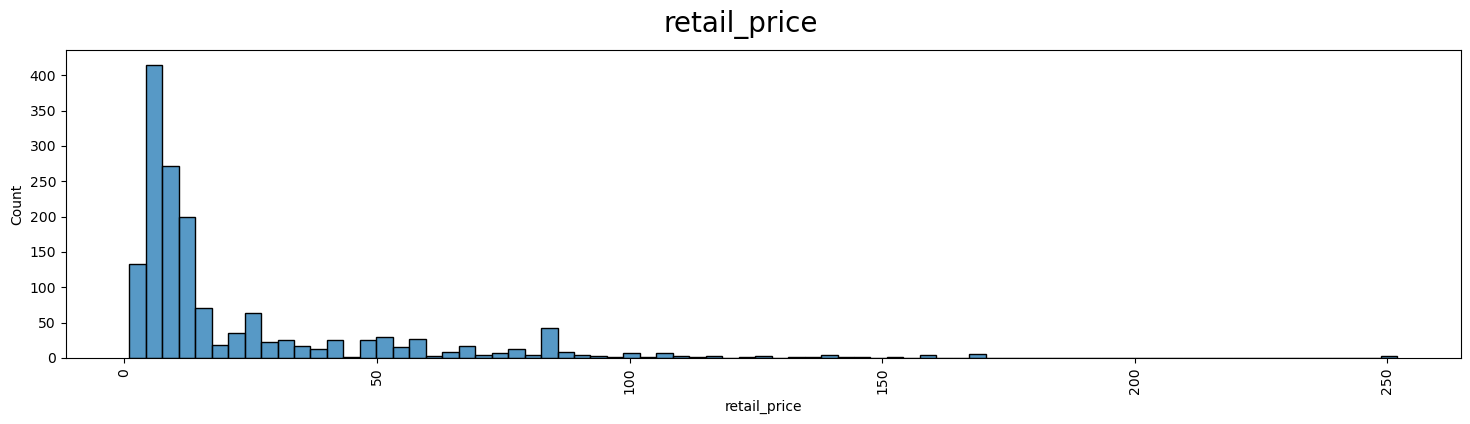

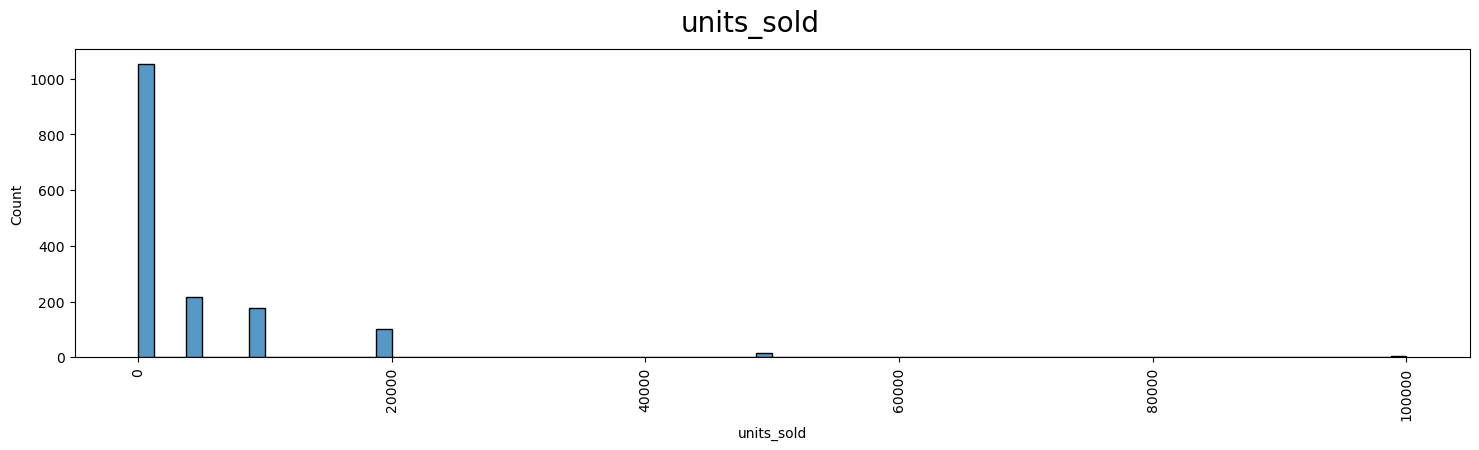

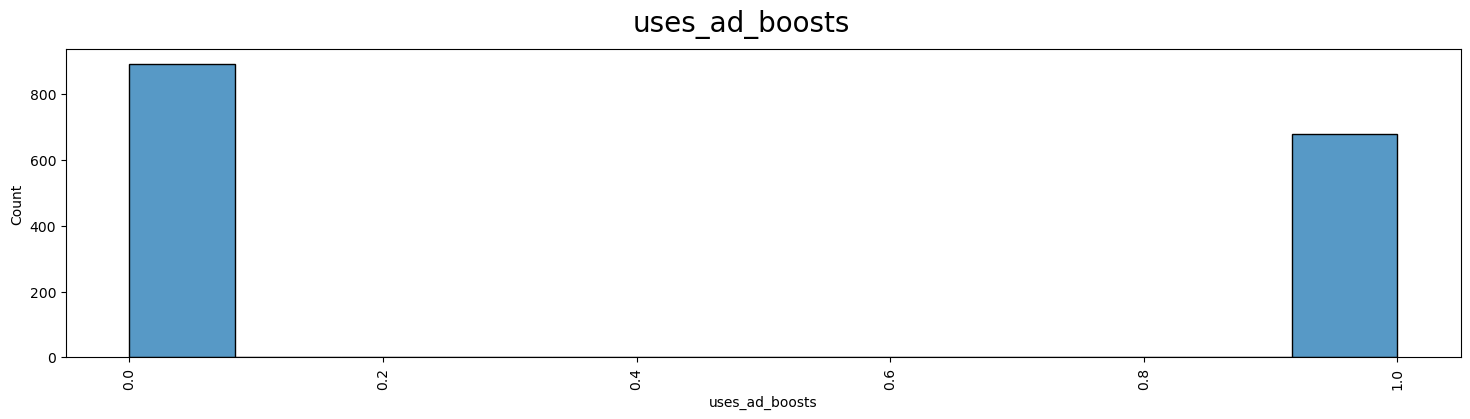

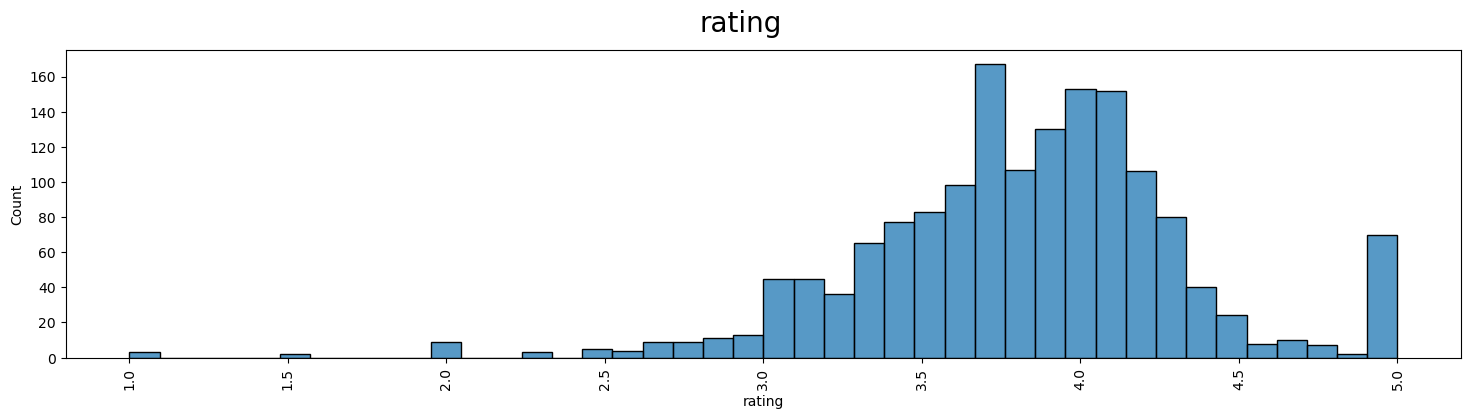

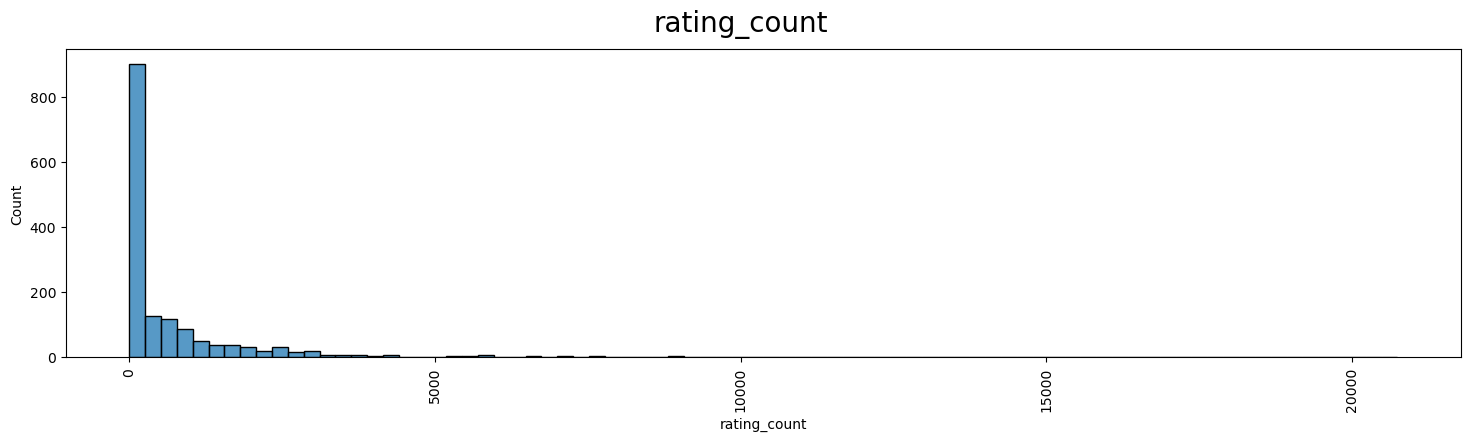

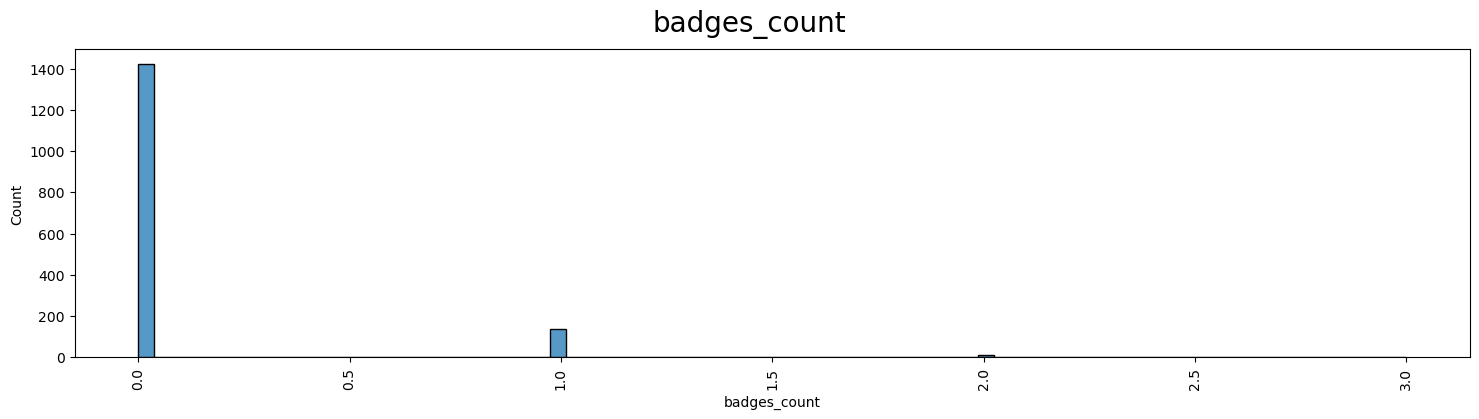

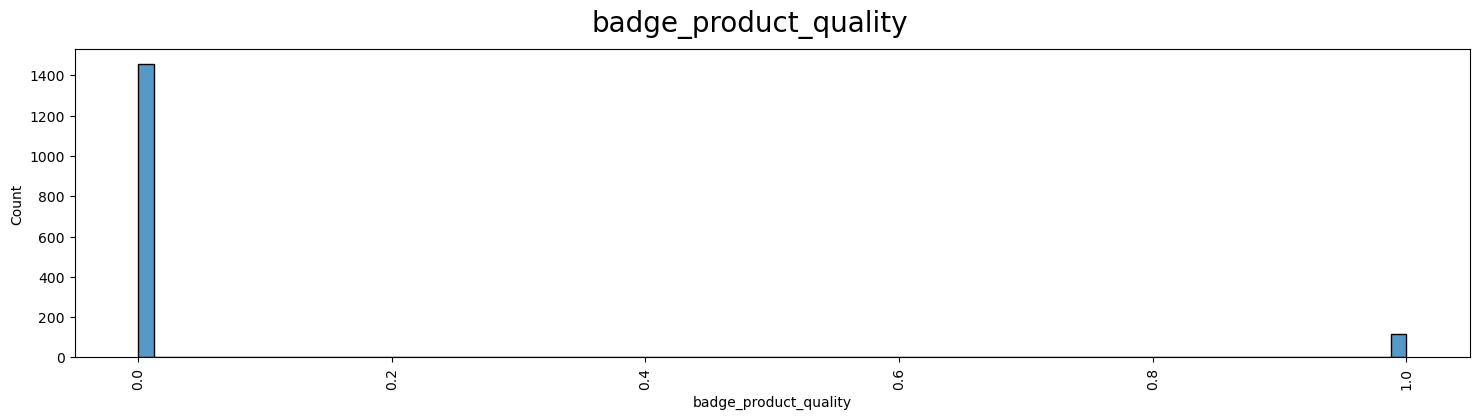

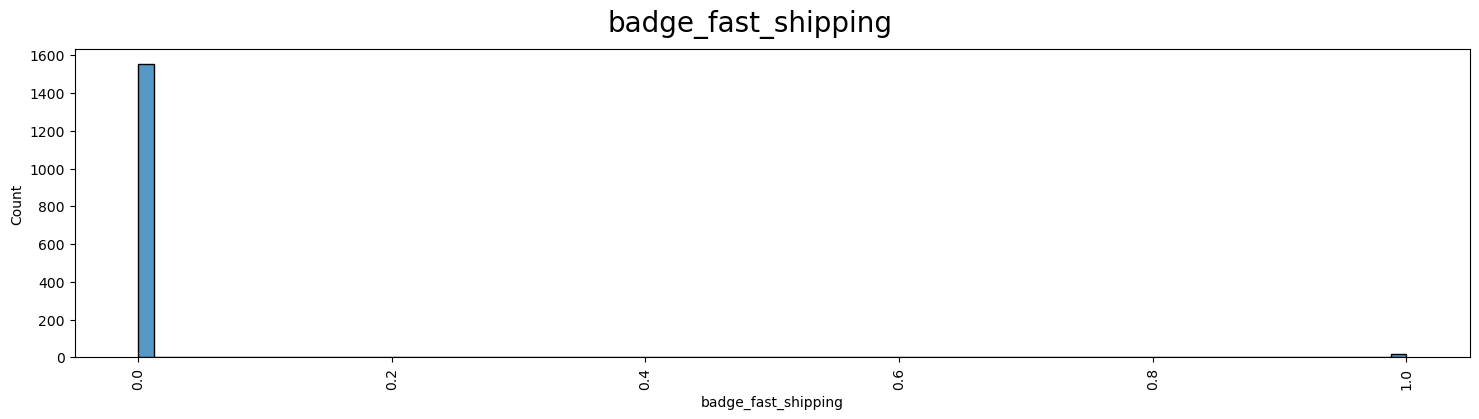

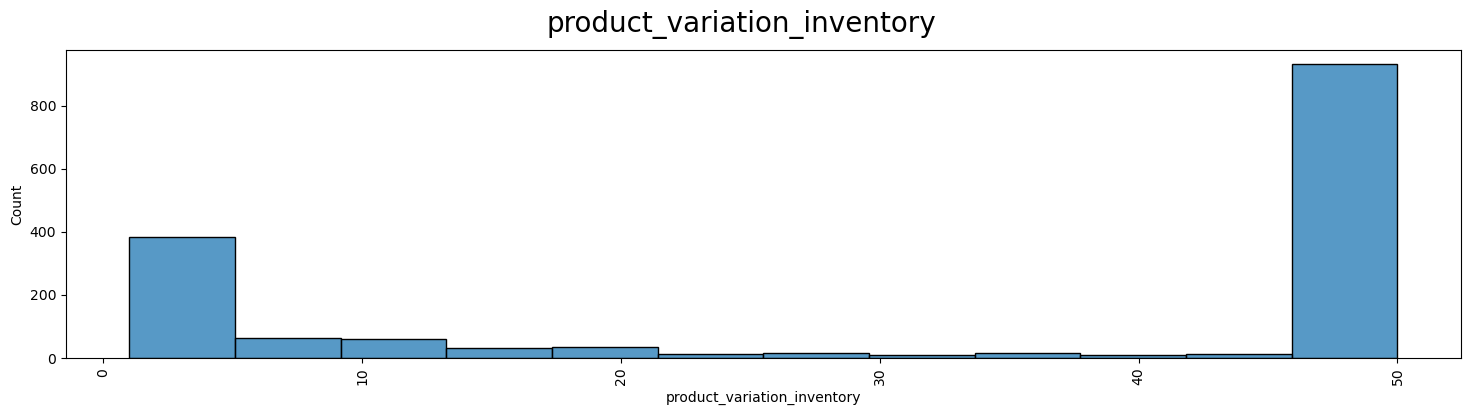

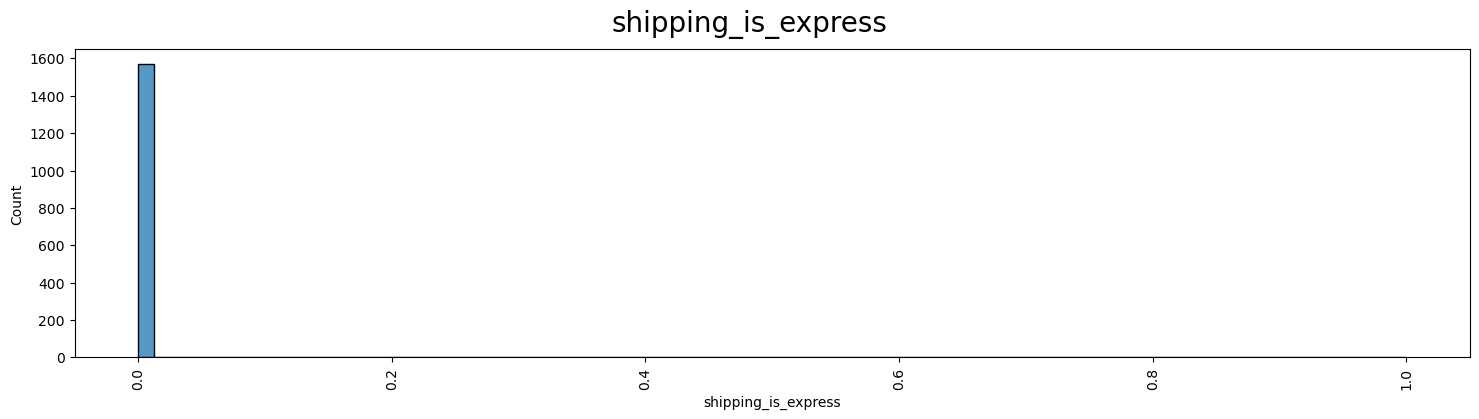

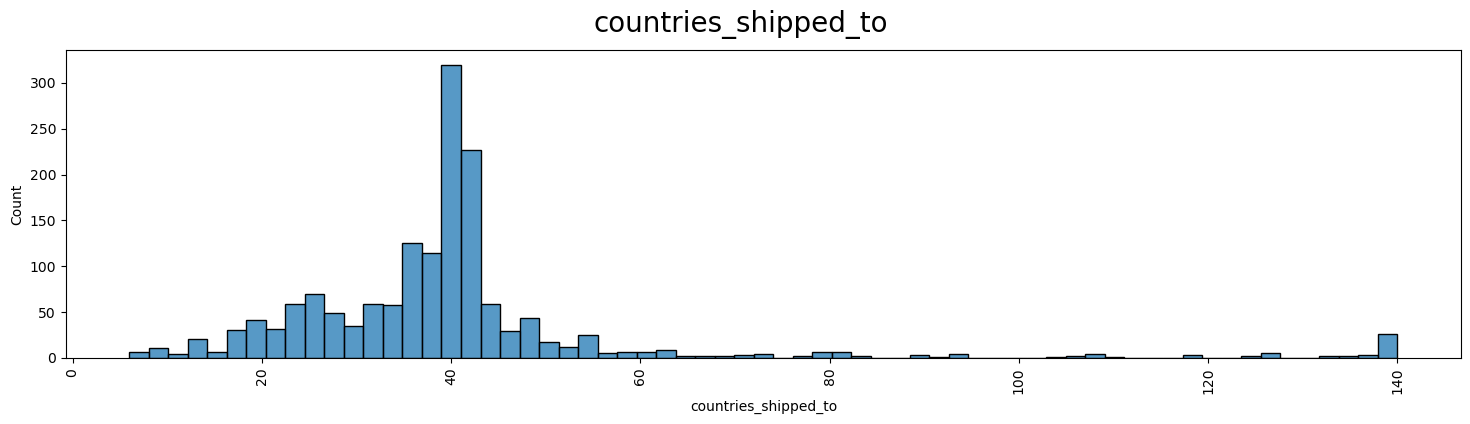

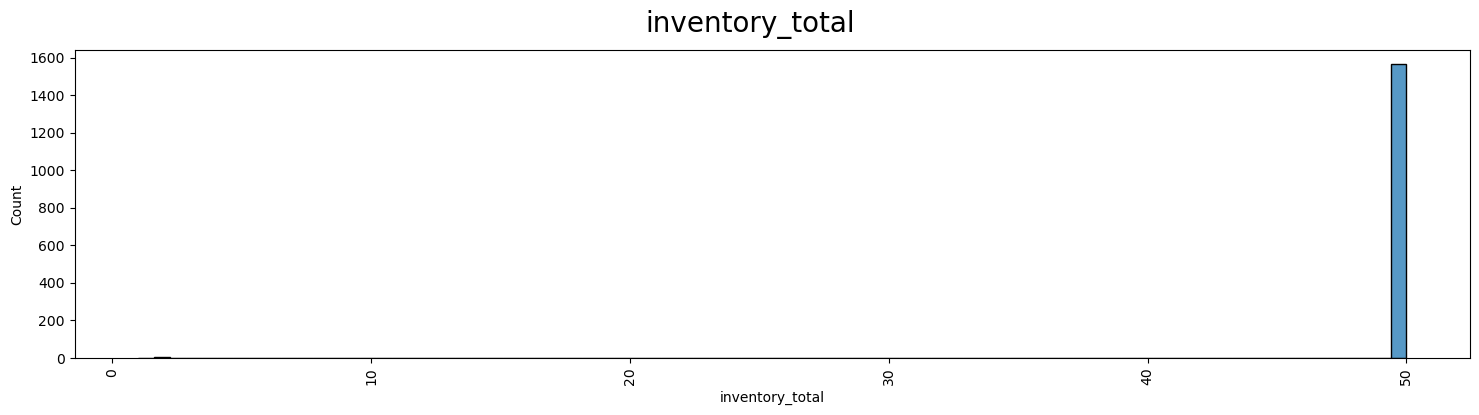

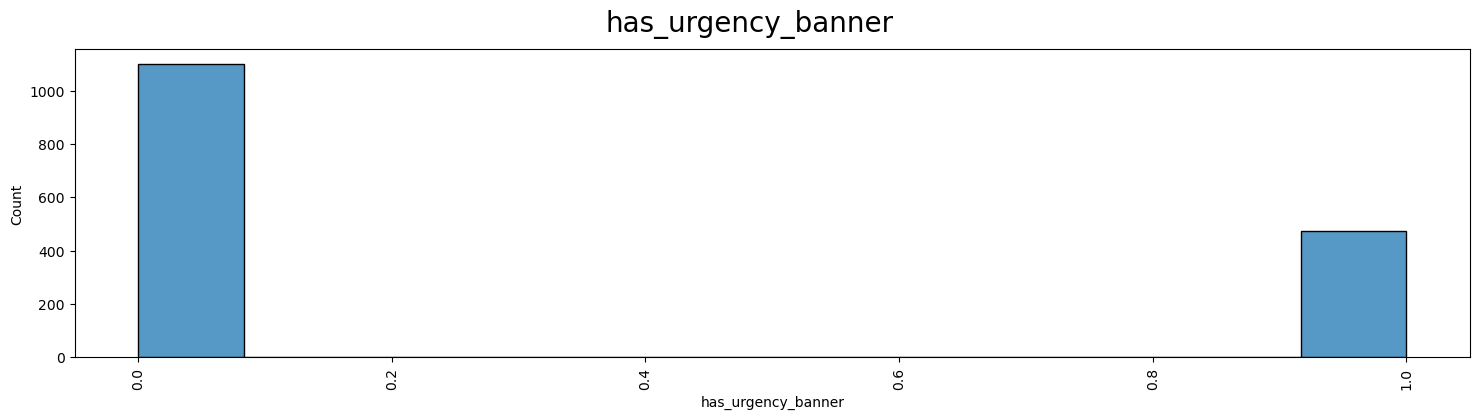

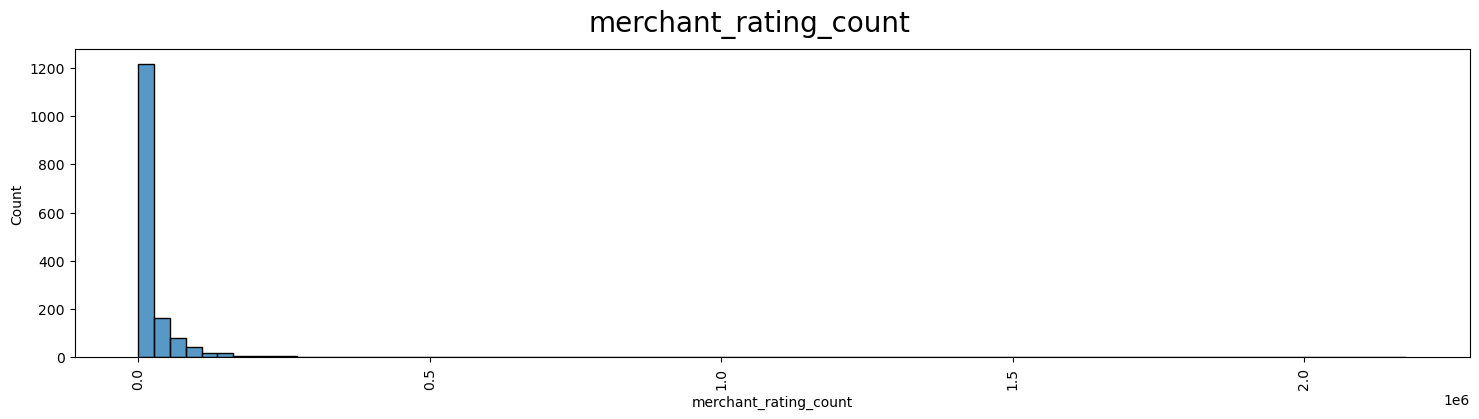

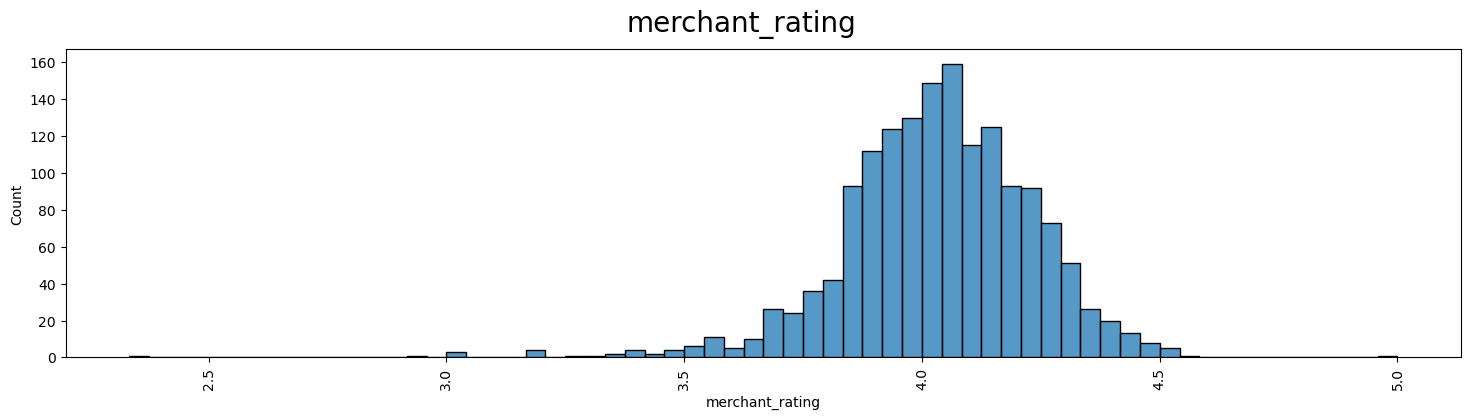

In [18]:
for colunas in colunas_numericas:
    f, axes = plt.subplots(1,1,figsize=(18,4))
    sns.histplot(x=colunas, data=df_produtos)
    plt.xticks(rotation=90)
    plt.suptitle(colunas,fontsize=20)
    plt.show()

A coluna "units_sold" precisará de uma correção, pois não é contínua

#### 2.1.3. Ajuste fino das colunas "tag" e "units sold"

**Units_sold**

In [19]:
df_produtos["units_sold"].value_counts()

units_sold
100       509
1000      405
5000      217
10000     177
20000     103
50         76
10         49
50000      17
100000      6
8           4
1           3
7           2
2           2
3           2
6           1
Name: count, dtype: int64

In [20]:
df_produtos

,title,price,retail_price,currency_buyer,units_sold,uses_ad_boosts,rating,rating_count,badges_count,badge_product_quality,...,product_color,product_variation_size_id,product_variation_inventory,shipping_is_express,countries_shipped_to,inventory_total,has_urgency_banner,origin_country,merchant_rating_count,merchant_rating
0,2020 Summer Vintage Flamingo Print Pajamas Se...,16.00,14,EUR,100,0,3.76,54,0,0,...,white,M,50,0,34,50,1.0,CN,568,4.128521
1,SSHOUSE Summer Casual Sleeveless Soirée Party ...,8.00,22,EUR,20000,1,3.45,6135,0,0,...,green,XS,50,0,41,50,1.0,CN,17752,3.899673
2,2020 Nouvelle Arrivée Femmes Printemps et Été ...,8.00,43,EUR,100,0,3.57,14,0,0,...,leopardprint,XS,1,0,36,50,1.0,CN,295,3.989831
3,Hot Summer Cool T-shirt pour les femmes Mode T...,8.00,8,EUR,5000,1,4.03,579,0,0,...,black,M,50,0,41,50,0.0,CN,23832,4.020435
4,Femmes Shorts d'été à lacets taille élastique ...,2.72,3,EUR,100,1,3.10,20,0,0,...,yellow,S,1,0,35,50,1.0,CN,14482,4.001588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1568,Nouvelle Mode Femmes Bohême Pissenlit Imprimer...,6.00,9,EUR,10000,1,4.08,1367,0,0,...,navyblue,S,50,0,41,50,0.0,CN,5316,4.224605
1569,10 couleurs femmes shorts d'été lacent ceintur...,2.00,56,EUR,100,1,3.07,28,0,0,...,lightblue,S,2,0,26,50,1.0,CN,4435,3.696054
1570,Nouveautés Hommes Siwmwear Beach-Shorts Hommes...,5.00,19,EUR,100,0,3.71,59,0,0,...,white,SIZE S,15,0,11,50,0.0,CN,210,3.961905
1571,Mode femmes d'été sans manches robes col en V ...,13.00,11,EUR,100,0,2.50,2,0,0,...,white,Size S.,36,0,29,50,0.0,CN,31,3.774194


In [21]:
df_produtos.loc[df_produtos["units_sold"] < 10, "units_sold"] = 10
df_produtos["units_sold"].value_counts()

units_sold
100       509
1000      405
5000      217
10000     177
20000     103
50         76
10         63
50000      17
100000      6
Name: count, dtype: int64

In [22]:
df_produtos["units_sold"].median() 

1000.0

In [23]:
df_produtos["units_sold"].mean() 

np.float64(4339.052765416402)

Como a mediana das vendas é 1000, vamos tentar entender que produtos ficaram acima desse patamar e quais ficaram abaixo.

**Tag**

In [24]:
from wordcloud import WordCloud, STOPWORDS

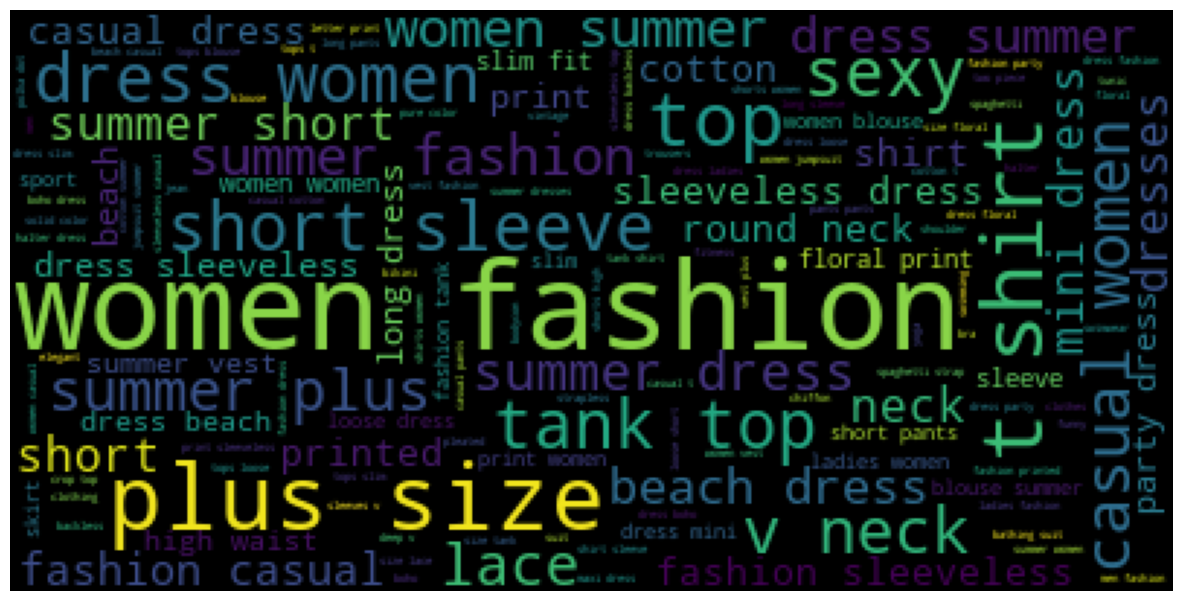

In [25]:
word_string = " ".join(df_produtos["tags"].str.lower())
wordcloud = WordCloud(stopwords=STOPWORDS).generate(word_string)

plt.subplots(figsize=(15,15))
plt.clf()
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### 2.2. Análise de produtos "campeões"

In [26]:
df_produtos["income"] = df_produtos["price"] * df_produtos["units_sold"]

<Axes: xlabel='income', ylabel='Count'>

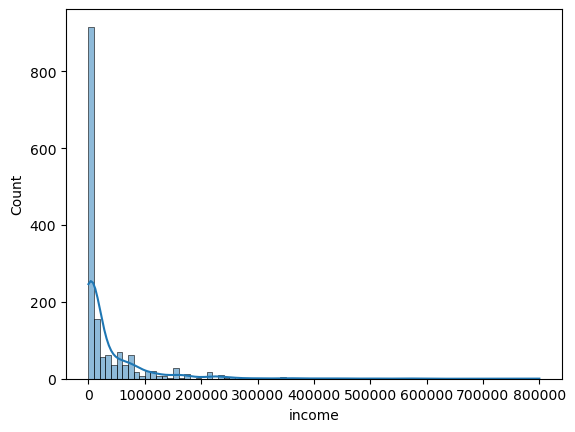

In [27]:
sns.histplot(df_produtos["income"], kde=True) 


In [28]:
for i in np.linspace(0, 1, 10):
    print("{:.2f} - {:.2f}".format(i, df_produtos["income"].quantile(i)))

0.00 - 20.00
0.11 - 369.00
0.22 - 700.00
0.33 - 1100.00
0.44 - 5000.00
0.56 - 8000.00
0.67 - 16000.00
0.78 - 49800.00
0.89 - 90000.00
1.00 - 800000.00


In [29]:
df_produtos["income"].median()

7000.0

In [30]:
df_produtos["income"].mean()

np.float64(35211.941703750796)

A diferença entre a média e a mediana quando a distribuição da variável observada não segue uma normal. Neste caso, vou me basear na mediana para análise

Vou tentar estudar os produtos com faturamento superior a $7.000.

In [56]:
df_produtos["success"] = 0
df_produtos.loc[df_produtos["income"] > 7000, "success"] = 1

#### Produtos com maior diferença entre "retail_price" e "price" vendem mais?**

In [32]:
df_produtos.columns

Index(['title', 'price', 'retail_price', 'currency_buyer', 'units_sold',
       'uses_ad_boosts', 'rating', 'rating_count', 'badges_count',
       'badge_product_quality', 'badge_fast_shipping', 'tags', 'product_color',
       'product_variation_size_id', 'product_variation_inventory',
       'shipping_is_express', 'countries_shipped_to', 'inventory_total',
       'has_urgency_banner', 'origin_country', 'merchant_rating_count',
       'merchant_rating', 'income', 'success'],
      dtype='object')

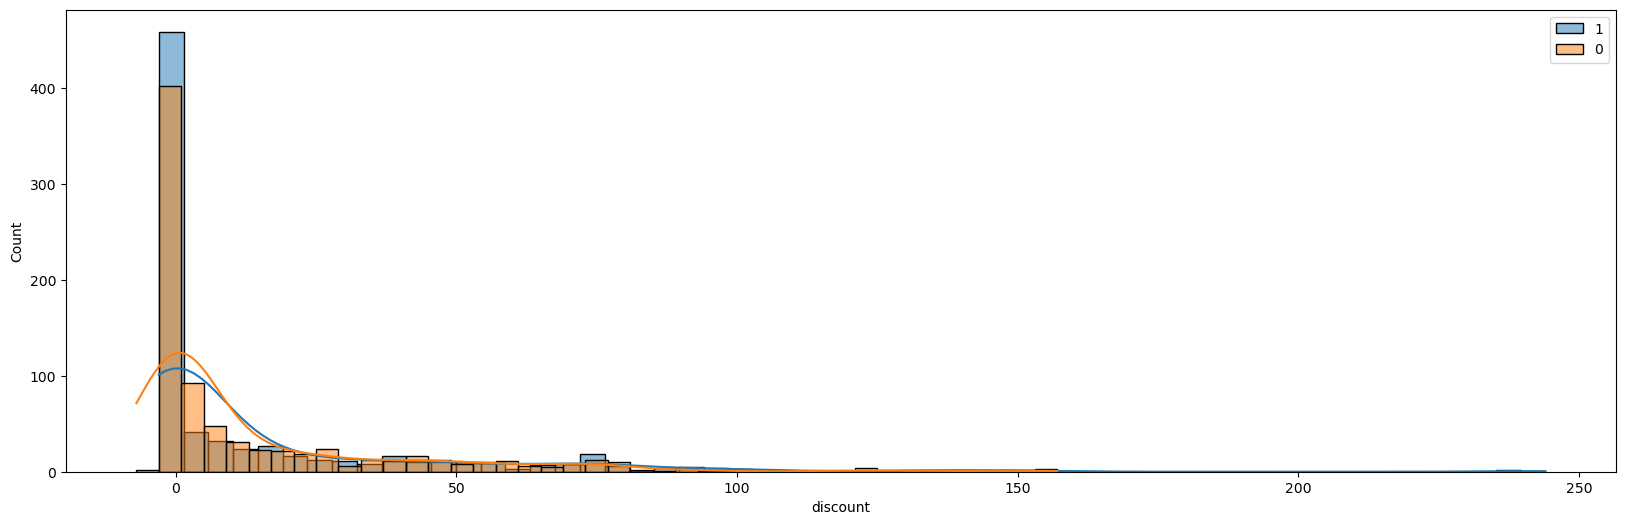

In [33]:
df_produtos["discount"] = df_produtos["retail_price"] - df_produtos["price"]

fig, ax = plt.subplots(figsize=(20, 6))
sns.histplot(df_produtos.loc[df_produtos["success"] == 1, "discount"], label="1", kde=True)
sns.histplot(df_produtos.loc[df_produtos["success"] == 0, "discount"], label="0", kde=True)
plt.legend()
plt.show()

#### Ad boost aumentam as vendas?

In [34]:
df_produtos.loc[df_produtos["success"] == 0, "uses_ad_boosts"].value_counts()

uses_ad_boosts
0    441
1    368
Name: count, dtype: int64

In [35]:
df_produtos.loc[df_produtos["success"] == 1, "uses_ad_boosts"].value_counts()

uses_ad_boosts
0    451
1    313
Name: count, dtype: int64

Aqui vemos que a maioria dos produtos vencedores não utilizam Ad boost

#### Avaliações melhores aumentam vendas?


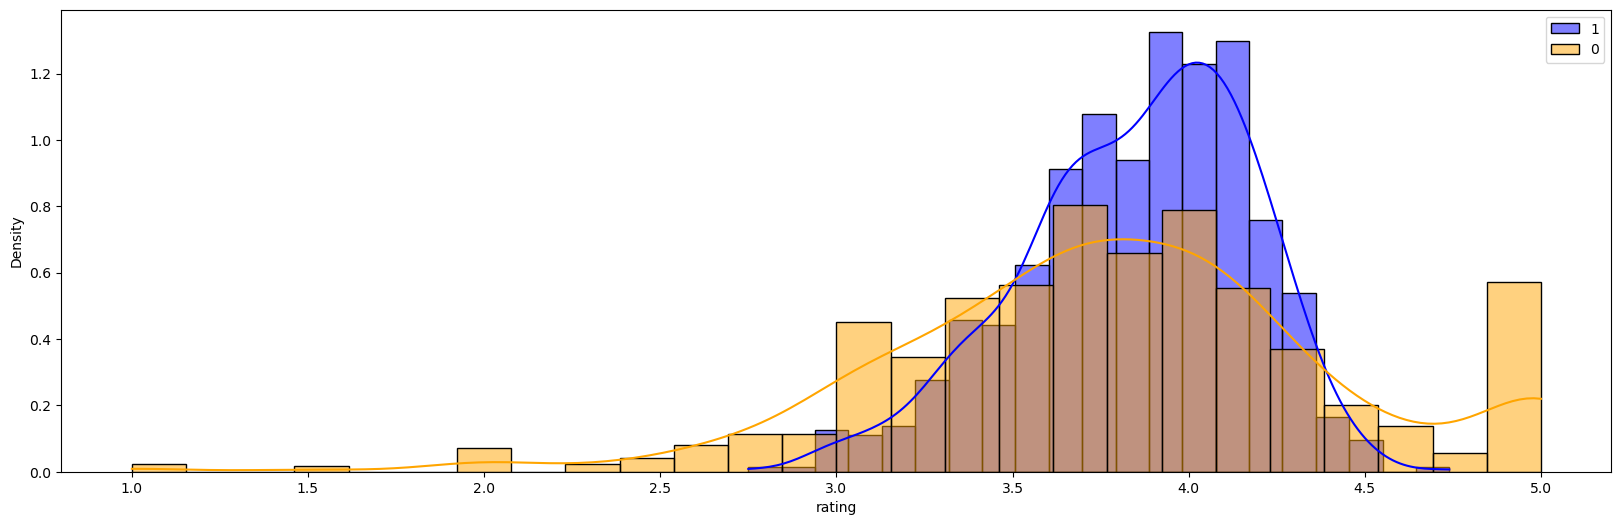

In [36]:
fig, ax = plt.subplots(figsize=(20, 6))

sns.histplot(df_produtos.loc[df_produtos["success"] == 1, "rating"], label="1", color="blue", kde=True, stat="density")
sns.histplot(df_produtos.loc[df_produtos["success"] == 0, "rating"], label="0", color="orange", kde=True, stat="density")

plt.legend()
plt.show()

Aqui vemos visualmente que produtos com boas avaliações vendem mais 

#### Badges importam?

In [37]:
df_produtos.groupby(["success", "badges_count"]).count()[["title"]].pivot_table(index="success", columns="badges_count").fillna(0)

title                
badges_count      0     1    2    3
success                            
0             753.0  48.0  8.0  0.0
1             669.0  90.0  3.0  2.0

In [38]:
df_produtos.groupby(["success", "badge_product_quality"]).count()[["title"]].pivot_table(index="success", columns="badge_product_quality").fillna(0)

title      
badge_product_quality      0     1
success                           
0                      770.0  39.0
1                      686.0  78.0

In [39]:
df_produtos.groupby(["success", "badge_fast_shipping"]).count()[["title"]].pivot_table(index="success", columns="badge_fast_shipping").fillna(0)

title      
badge_fast_shipping      0     1
success                         
0                    795.0  14.0
1                    758.0   6.0

A princípio parece que as badges não indicam nada no impacto das vendas. 

#### Quantidade de tags auxiliam vendas?

In [40]:
df_produtos["tags"]

0       Summer,Fashion,womenunderwearsuit,printedpajam...
1       Mini,womens dresses,Summer,Patchwork,fashion d...
2       Summer,cardigan,women beachwear,chiffon,Sexy w...
3       Summer,Shorts,Cotton,Cotton T Shirt,Sleeve,pri...
4       Summer,Plus Size,Lace,Casual pants,Bottom,pant...
                              ...                        
1568    bohemia,Plus Size,dandelionfloralprinted,short...
1569    Summer,Panties,Elastic,Lace,Casual pants,casua...
1570    runningshort,Beach Shorts,beachpant,menbeachsh...
1571    Summer,fashion women,Fashion,Lace,Dresses,Dres...
1572    Summer,Leggings,slim,Yoga,pants,Slim Fit,Women...
Name: tags, Length: 1573, dtype: object

In [41]:
df_produtos["tags_count"] = df_produtos["tags"].apply(lambda x: len(x.split(",")))

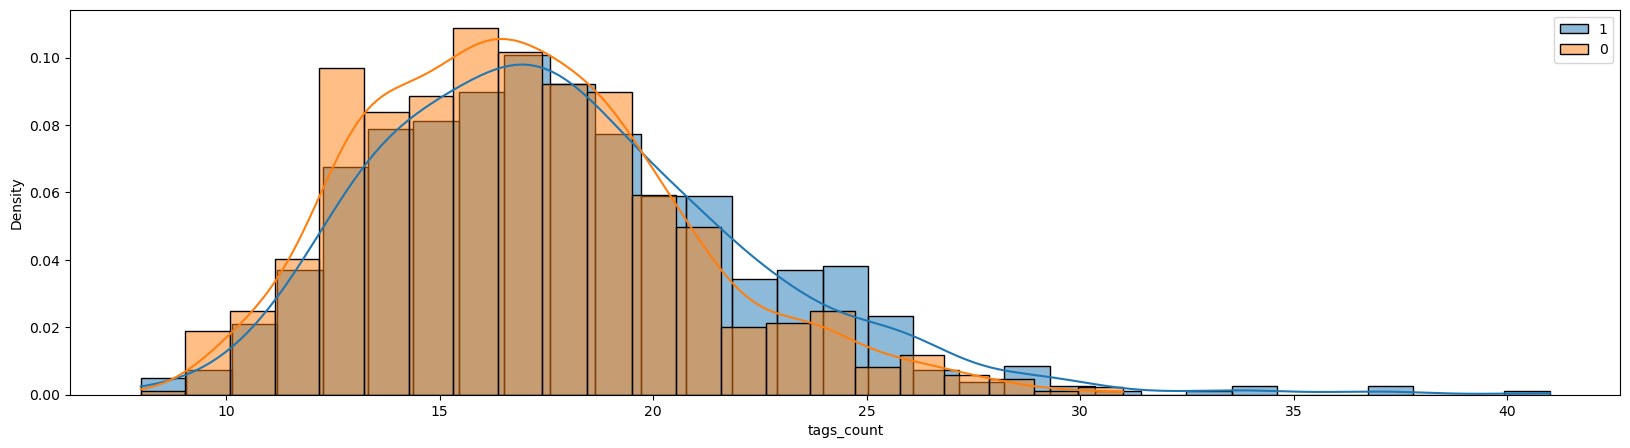

In [42]:
df_produtos["discount"] = df_produtos["retail_price"] - df_produtos["price"]

fig, ax = plt.subplots(figsize=(20, 5))
sns.histplot(df_produtos.loc[df_produtos["success"] == 1, "tags_count"], label="1", kde=True, stat="density")
sns.histplot(df_produtos.loc[df_produtos["success"] == 0, "tags_count"], label="0", kde=True, stat="density")
plt.legend()
plt.show()

Produtos que tem uma contagem maior de tags tendem a vender mais que produtos sem tags ou com um menor número.

#### Tags com maiores vendas?

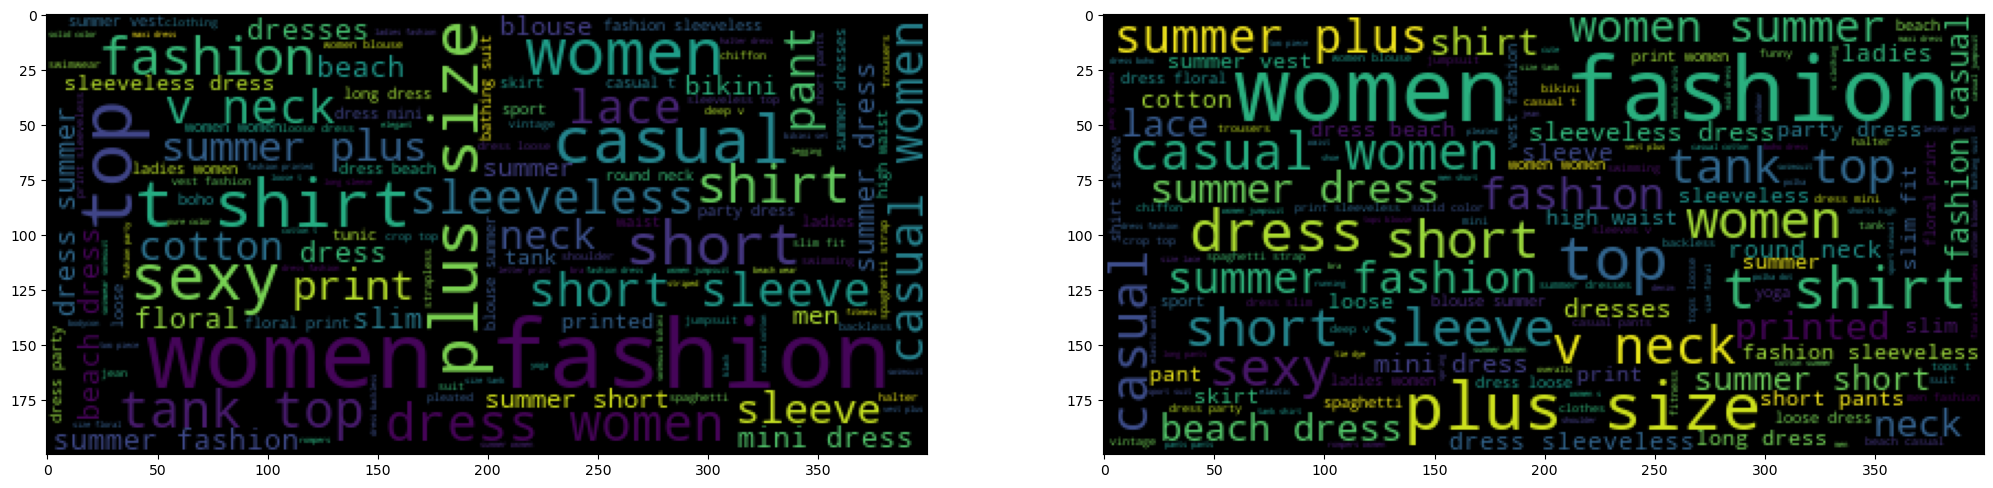

In [43]:
df_tags_sucesso = df_produtos.loc[df_produtos["success"] == 1]
word_string=" ".join(df_tags_sucesso["tags"].str.lower())
wordcloud_sucesso = WordCloud(stopwords=STOPWORDS).generate(word_string)

df_tags_falhas = df_produtos.loc[df_produtos["success"] == 0]
word_string=" ".join(df_tags_falhas["tags"].str.lower())
wordcloud_falha = WordCloud(stopwords=STOPWORDS).generate(word_string)

fig, ax = plt.subplots(1, 2, figsize=(25,20))
ax[0].imshow(wordcloud_sucesso)
ax[1].imshow(wordcloud_falha)

plt.show()

**Que palavras aparecem mais nos produtos que vendem mais e menos?**

In [44]:
tags = []
for list_tags in df_tags_sucesso["tags"].values:
    tags += list_tags.split(",")
pd.Series(tags).value_counts().head(5)

Women's Fashion    665
Summer             580
Fashion            527
Women              504
Casual             429
Name: count, dtype: int64

In [45]:
tags = []
for list_tags in df_tags_falhas["tags"].values:
    tags += list_tags.split(",")
pd.Series(tags).value_counts().head(5)

Summer             741
Women's Fashion    650
Fashion            555
Casual             476
Women              457
Name: count, dtype: int64

#### Shipping analysis

In [46]:
df_produtos.groupby(["success", "shipping_is_express"]).count()[["title"]].pivot_table(index="success", columns="shipping_is_express").fillna(0)

title     
shipping_is_express      0    1
success                        
0                    807.0  2.0
1                    762.0  2.0

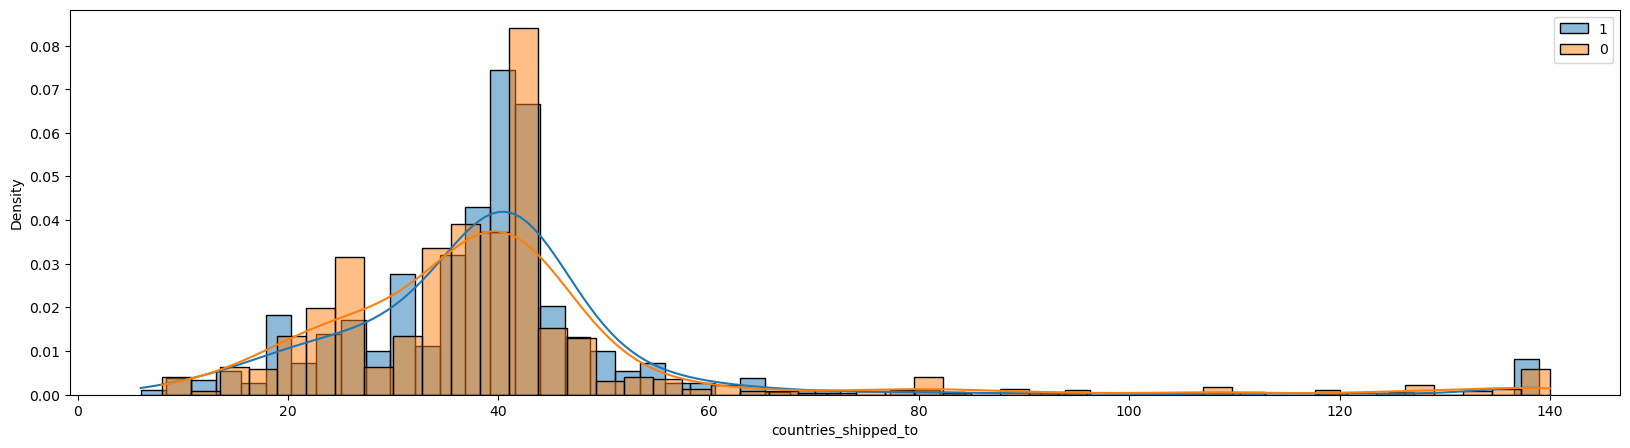

In [47]:
df_produtos["discount"] = df_produtos["retail_price"] - df_produtos["price"]

fig, ax = plt.subplots(figsize=(20, 5))
sns.histplot(df_produtos.loc[df_produtos["success"] == 1, "countries_shipped_to"], label="1", kde=True, stat="density")
sns.histplot(df_produtos.loc[df_produtos["success"] == 0, "countries_shipped_to"], label="0", kde=True, stat="density")
plt.legend()
plt.show()

## 3. Machine Learning

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
colunas_modelo = ["price", "retail_price", 
       "uses_ad_boosts", "rating", "badges_count",
       "badge_product_quality", "badge_fast_shipping", "product_variation_inventory",
       "shipping_is_express", "countries_shipped_to", "inventory_total",
       "has_urgency_banner", 
       "merchant_rating", "discount", "tags_count"]

x = df_produtos[colunas_modelo]
y = df_produtos["success"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [50]:
from sklearn.model_selection import GridSearchCV 
from sklearn.ensemble import RandomForestClassifier 

param_grid = [ 
    {"n_estimators": [3, 10, 30], "max_features": [2, 4, 6, 8]}, 
    {"bootstrap": [False], "n_estimators": [3, 10], "max_features": [2, 3, 4]}, 
]

forest_reg = RandomForestClassifier() 
grid_search = GridSearchCV(forest_reg, param_grid, cv=5, 
                           return_train_score=True) 

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True)

In [51]:
grid_search.best_params_
rf_model = grid_search.best_estimator_

In [52]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf_model.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77       250
           1       0.75      0.72      0.73       222

    accuracy                           0.75       472
   macro avg       0.75      0.75      0.75       472
weighted avg       0.75      0.75      0.75       472

[[196  54]
 [ 63 159]]


<Axes: >

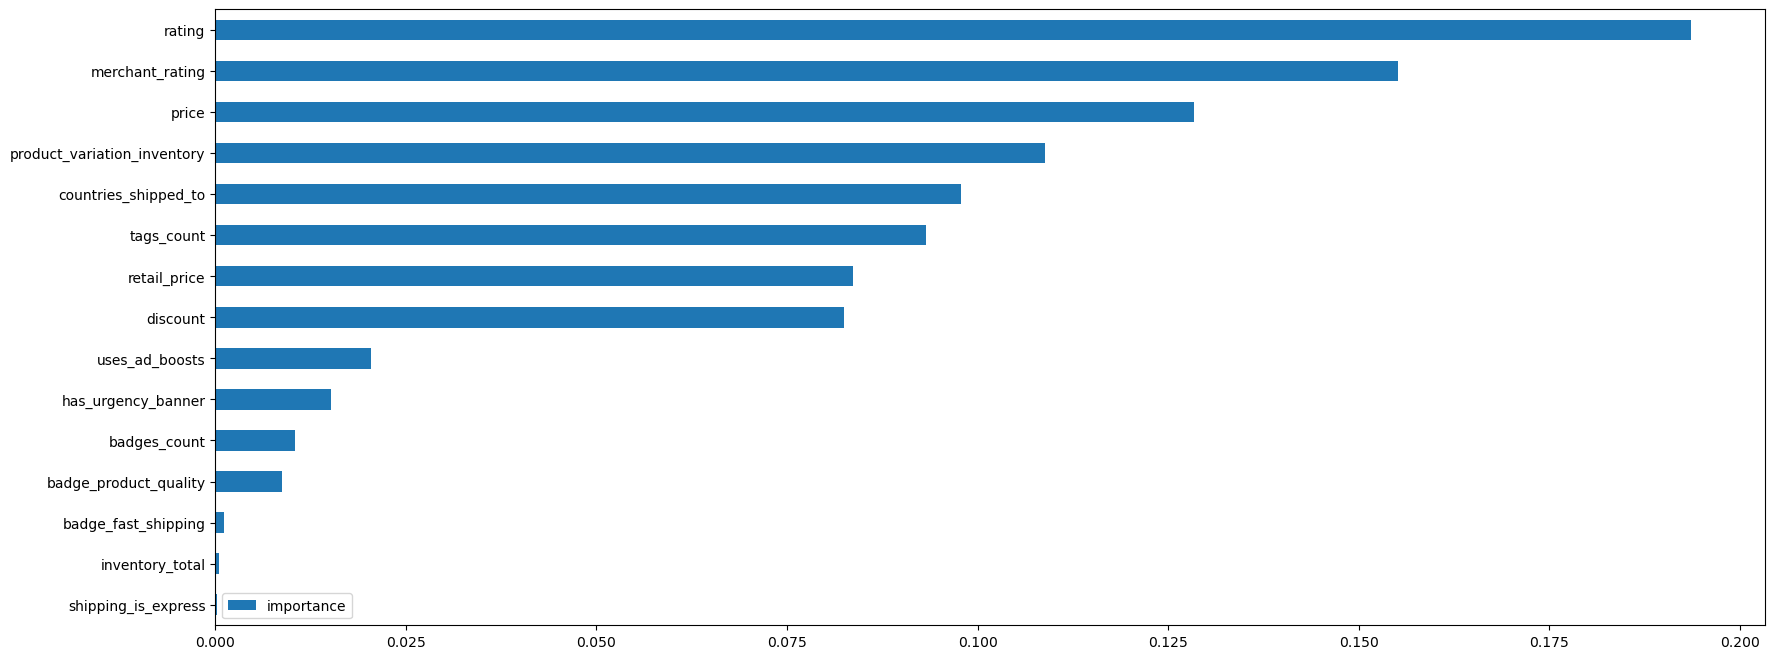

In [53]:
feature_importances = pd.DataFrame(rf_model.feature_importances_,
                                   index = x.columns,
                                    columns=["importance"]).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(20, 8))
feature_importances.plot(kind="barh", ax=ax)

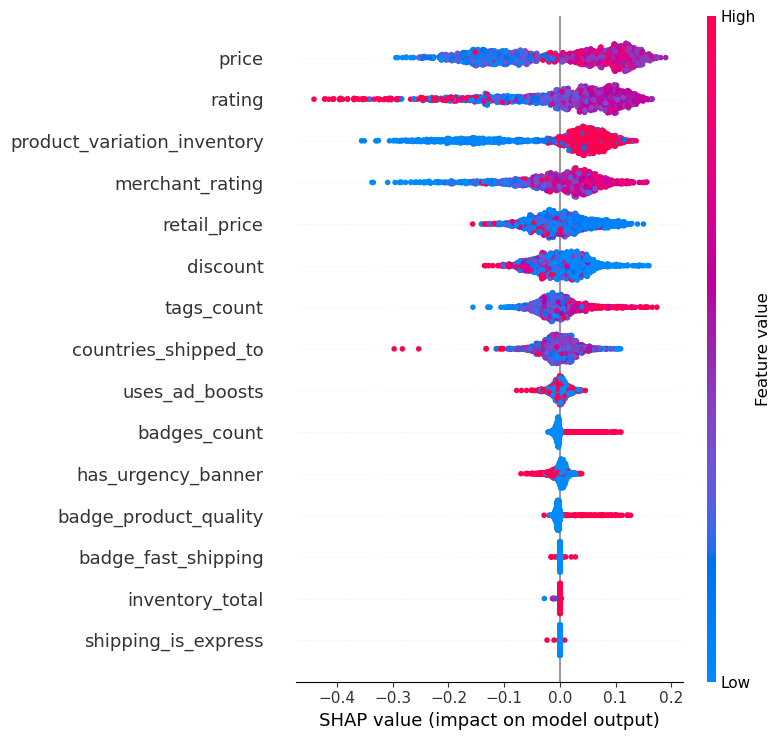

In [54]:
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(x)

shap.summary_plot(shap_values[:, :, 1], x)

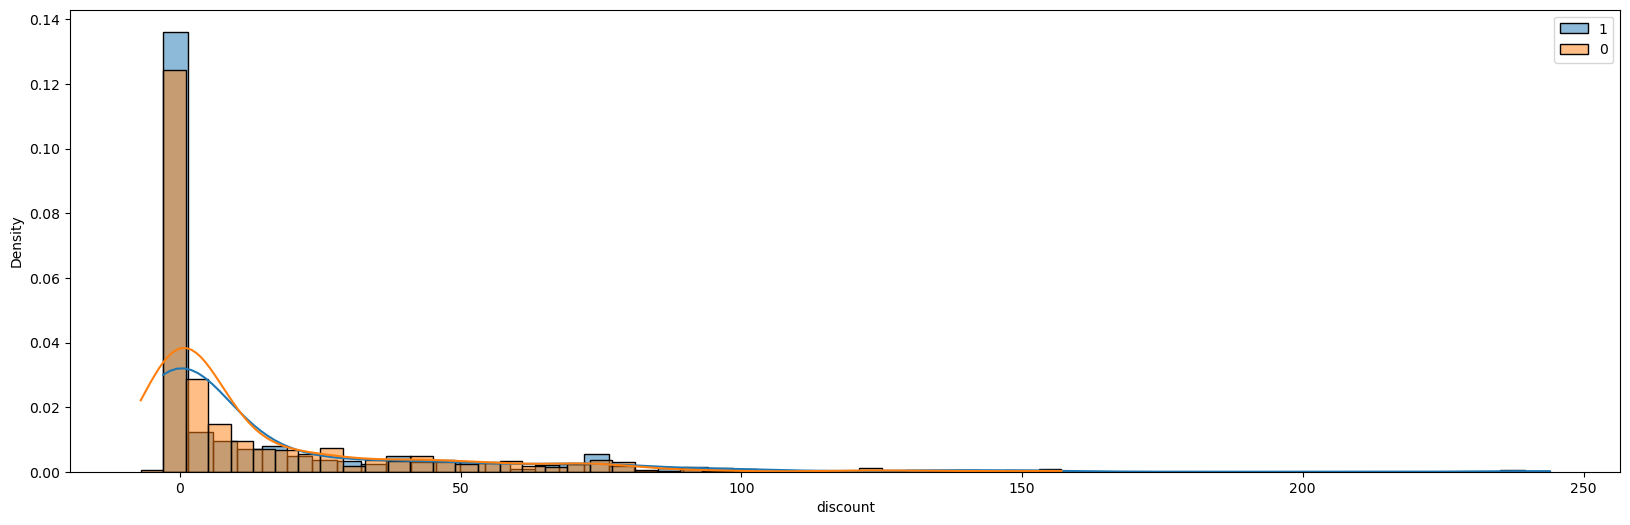

In [55]:
df_produtos["discount"] = df_produtos["retail_price"] - df_produtos["price"]
fig, ax = plt.subplots(figsize=(20, 6))
sns.histplot(df_produtos.loc[df_produtos["success"] == 1, "discount"], 
             label="1", kde=True, stat="density")
sns.histplot(df_produtos.loc[df_produtos["success"] == 0, "discount"], 
             label="0", kde=True, stat="density")
plt.legend()

## 4. Conclusões

Este projeto teve como objetivo identificar os principais fatores que influenciam o sucesso de produtos de verão na plataforma Wish, utilizando análise exploratória de dados e validação de hipóteses levantadas inicialmente.

Os resultados indicam que o desempenho dos produtos não está associado a um único fator isolado, mas sim à combinação de múltiplas variáveis. Entre os principais insights obtidos:

Avaliações (ratings) e volume de avaliações demonstraram forte relação com o número de vendas, indicando que prova social é um dos principais drivers de conversão.

Diferença entre preço real e preço de varejo (desconto percebido) mostrou impacto relevante, sugerindo que estratégias de precificação psicológica influenciam diretamente o comportamento do consumidor.

O uso de ad boosts apresentou efeito positivo, porém não determinante, indicando que visibilidade auxilia, mas não substitui atributos de qualidade do produto.

Badges (qualidade e envio rápido) contribuem para aumento de vendas, reforçando a importância de sinais de confiança na decisão de compra.

Variáveis como quantidade de tags, países atendidos e logística (shipping) também demonstraram influência, embora com menor impacto isolado.

De forma geral, produtos com boa reputação, percepção de valor (desconto), e sinais de confiabilidade tendem a performar significativamente melhor.